In [14]:
#GUILBERT--ARRUGA Leo, JEBALI Ibtissem, M2 BIDABI
#
import pandas as pd #import packages
import matplotlib.pyplot as plt
import seaborn as sns
import re
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score


In [15]:
data = pd.read_csv('training.1600000.processed.noemoticon.csv', encoding='latin-1', header=None) #charger csv
data.columns = ['target', 'ids', 'date', 'flag', 'user', 'text'] #attribuer noms colonnes
data.head(5)#afficher 5 premieres lignes du df

,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [16]:
df = data[['target', 'text']] #garder uniquement target et text pour le modele
df['target'] = df['target'].map({0: 0, 4: 1})  # 0 = négatif en 0, 1 = positif en 4
df = df.drop_duplicates() #supprimer doublons
df['target'].unique() #verifier valeur unique de target

C:\Users\leogu\AppData\Local\Temp\ipykernel_17460\1282833142.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['target'] = df['target'].map({0: 0, 4: 1})  # 0 = négatif en 0, 1 = positif en 4


array([0, 1])

C:\Users\leogu\AppData\Local\Temp\ipykernel_17460\3375453524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['target'], palette='viridis')


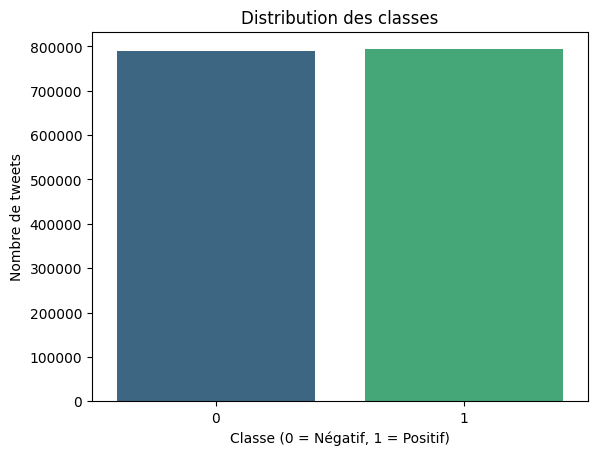

In [17]:
#graph distrib classe de target
sns.countplot(x=df['target'], palette='viridis')
plt.title("Distribution des classes")
plt.xlabel("Classe (0 = Négatif, 1 = Positif)")
plt.ylabel("Nombre de tweets")
plt.show()

In [18]:
def clean_tweet(tweet): #creer une fonction pour nettoyer le texte
    tweet = re.sub(r'http\S+', '', tweet)  #supprimer les URLs
    tweet = re.sub(r'@\w+', '', tweet)  #supprimer les mentions
    tweet = re.sub(r'#\w+', '', tweet)  #supprimer les hashtags
    tweet = re.sub(r'[^\w\s]', '', tweet)  #supprimer les caractères spéciaux
    return tweet.lower() #convertir minuscule
df['clean_text'] = df['text'].apply(clean_tweet) #creer une nv colonne avec texte propre

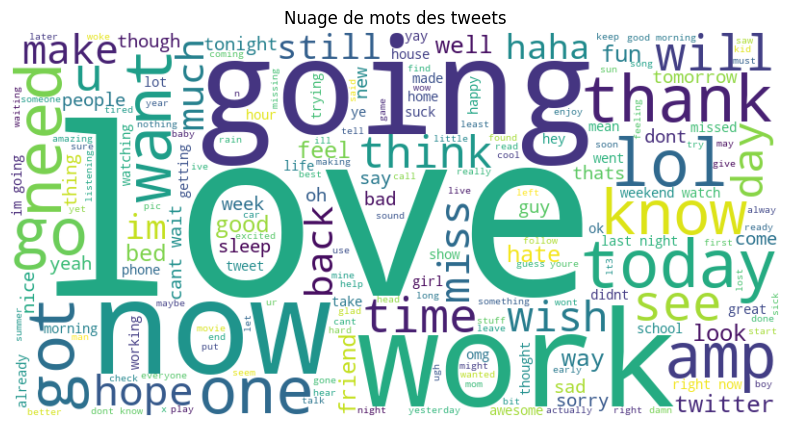

In [19]:
all_words = ' '.join(df['clean_text']) #combiner tous les texte en une ligne
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(all_words) #creer nuage de mot
#graph nuage de mot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  #supprimer axes
plt.title("Nuage de mots des tweets")
plt.show()

In [20]:
df = df.dropna(subset=['clean_text']) #supprimer ligne sans cleantext
df['clean_text'] = df['clean_text'].astype(str) #convertir en chaine de caractere

In [21]:
vectorizer = CountVectorizer(max_features=10000, stop_words='english')  #vectoriser texte, limite 10000
X = vectorizer.fit_transform(df['clean_text'])  #matrice creuse sinon pb memoire
y = df['target']  #etiquette, pos ou neg

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #test 20%

In [23]:
#modele Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
#pred sur test
y_pred_nb = nb.predict(X_test)
#eval modele
print("Naive Bayes - Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Rapport de classification :")
print(classification_report(y_test, y_pred_nb))

Naive Bayes - Accuracy: 0.7610461610347952
Rapport de classification :
              precision    recall  f1-score   support

           0       0.76      0.75      0.76    157487
           1       0.76      0.77      0.76    159252

    accuracy                           0.76    316739
   macro avg       0.76      0.76      0.76    316739
weighted avg       0.76      0.76      0.76    316739



In [12]:
#modele regression logistique
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
#pred sur test
y_pred_logreg = logreg.predict(X_test)
#eval modele
print("Logistic Regression - Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("Rapport de classification :")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression - Accuracy: 0.7699272902926384
Rapport de classification :
              precision    recall  f1-score   support

           0       0.79      0.73      0.76    157487
           1       0.75      0.80      0.78    159252

    accuracy                           0.77    316739
   macro avg       0.77      0.77      0.77    316739
weighted avg       0.77      0.77      0.77    316739



C:\Users\leogu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
#modele svm
svm_model = LinearSVC()
svm_model.fit(X_train, y_train)
#pred sur test
y_pred_svm = svm_model.predict(X_test)
#eval perf
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM - Accuracy: {accuracy_svm}")
print("Rapport de classification :")
print(classification_report(y_test, y_pred_svm))


SVM - Accuracy: 0.7691727258089468
Rapport de classification :
              precision    recall  f1-score   support

           0       0.79      0.73      0.76    157487
           1       0.75      0.81      0.78    159252

    accuracy                           0.77    316739
   macro avg       0.77      0.77      0.77    316739
weighted avg       0.77      0.77      0.77    316739

